In [1]:
import numpy as np
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder, IRAFStarFinder
from astropy import stats
from astropy import wcs
from astropy.table import Table
import glob
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt

basepath = '/orange/adamginsburg/jwst/w51/'

def load_data(filename):
    fh = fits.open(filename)
    im1 = fh
    im1.info()
    try:
        data = im1[1].data
    except:
        data = im1[0].data
    try:
        wht = im1['WHT'].data
    except KeyError:
        wht = None
    err = im1['ERR'].data
    instrument = im1[0].header['INSTRUME']
    telescope = im1[0].header['TELESCOP']
    obsdate = im1[0].header['DATE-OBS']
    return fh, im1, data, wht, err, instrument, telescope, obsdate


def check_daofind(data, filename, filtername, thres_num = 4, roundhi=1.0, roundlo=-1.0, sharplo=0.1, sharphi=1.4): 
    
    fwhm_tbl = Table.read(f'{basepath}/reduction/fwhm_table.ecsv')
    row = fwhm_tbl[fwhm_tbl['Filter'] == filtername]
    fwhm = fwhm_arcsec = float(row['PSF FWHM (arcsec)'][0])
    fwhm_pix = float(row['PSF FWHM (pixel)'][0])
    fh, im1, data, wht, err, instrument, telescope, obsdate = load_data(filename)
    filtered_errest = stats.sigma_clipped_stats(data, stdfunc='mad_std')
    print(f'Error estimate for DAO from stats.: {filtered_errest}', flush=True)
    filtered_errest = np.nanmedian(err)
    print(f'Error estimate for DAO from median(err): {filtered_errest}', flush=True)
    daofind_tuned = DAOStarFinder(threshold=  thres_num * filtered_errest,
                                    fwhm=fwhm_pix, roundhi=roundhi, roundlo=roundlo,
                                    sharplo=sharplo, sharphi=sharphi)
    finstars = daofind_tuned(np.nan_to_num(data))



    #finstars['x'] = finstars['xcentroid']
    #finstars['y'] = finstars['ycentroid']
    finstars.pprint_all()
    finstars.write(f'daofind_check_tabs/{filtername}/{filename.replace(".fits","").split("/")[-1]}_daofind.fits', overwrite=True)

    fig = plt.figure(figsize=(30,15))
    ax = fig.add_subplot(1,1,1)
    norm = simple_norm(data, 'log', percent=99.5)
    ax.imshow(data, origin='lower', cmap='inferno', norm=norm)
    ax.scatter(finstars['xcentroid'], finstars['ycentroid'], s=100, edgecolor='cyan', facecolor='none', lw=1, alpha=0.5)
    plt.savefig(f'daofind_check_figs/{filtername}/{filename.replace(".fits","").split("/")[-1]}_daofind.png', dpi=150)
    plt.show()

    plt.close()
    

def get_filenames(basepath, filtername, proposal_id, field, each_suffix, module, pupil='clear', visitid='001'):

    # jw01182004002_02101_00012_nrcalong_destreak_o004_crf.fits
    # jw02221001001_07101_00012_nrcalong_destreak_o001_crf.fits
    # jw02221001001_05101_00022_nrcb3_destreak_o001_crf.fits
    glstr = f'{basepath}/{filtername}/pipeline/jw0{proposal_id}{field}{visitid}*{module}*_{each_suffix}.fits'
    
  
    fglob = glob.glob(glstr)
    print(fglob)
    fglob_remove = []
    for st in fglob:
        print(st)
        if 'align' in st or 'uncal' in st or 'outlier' in st:
            print(f"Removing {st} from glob string because it is an alignment file")
            fglob_remove.append(st)
    for st in fglob_remove:
        fglob.remove(st)
    if len(fglob) == 0:
        raise ValueError(f"No matches found to {glstr}")
    else:
        return fglob
def main(numcount=1, filtername='F480M', proposal_id='6151', field='001', visitid='001', module='nrca', each_suffix='i2d'):
    numcount=0
    filenames = get_filenames(basepath, filtername, proposal_id, field, each_suffix, module, visitid=visitid)
    print('filenames')
    print(filenames)
    for filename in filenames:
        print(f'Filename: {filename}', flush=True)
        check_daofind(data=None, filename=filename, filtername=filtername)
        numcount += 1
        if numcount >= 1:
            break


/home/t.yoo/anaconda3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00008_nrcalong_outlier_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00003_nrcalong_outlier_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00003_nrcalong_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00002_nrcalong_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00006_nrcalong_outlier_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00005_nrcalong_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00005_nrcalong_outlier_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00002_nrcalong_outlier_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00004_nrcalong_i2d.fits', '/orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00001_nrcalong_i2d.fits', '/orange/adamginsburg/jwst/w5

Filename: /orange/adamginsburg/jwst/w51//F480M/pipeline/jw06151001001_03109_00003_nrcalong_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     371   ()      
  1  SCI           1 ImageHDU        75   (2075, 2068)   float32   
  2  ERR           1 ImageHDU        10   (2075, 2068)   float32   
  3  CON           1 ImageHDU        10   (2075, 2068, 1)   int32   
  4  WHT           1 ImageHDU         9   (2075, 2068)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2075, 2068)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2075, 2068)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2075, 2068)   float32   
  8  ASDF          1 BinTableHDU     11   1R x 1C   [14177B]   
Error estimate for DAO from stats.: (np.float32(13.501071), np.float32(12.903764), np.float32(6.2690196))
Error estimate for DAO from median(err): 0.29530423879623413
  id      xcentroid          ycentroid           sharpness        roundness1  

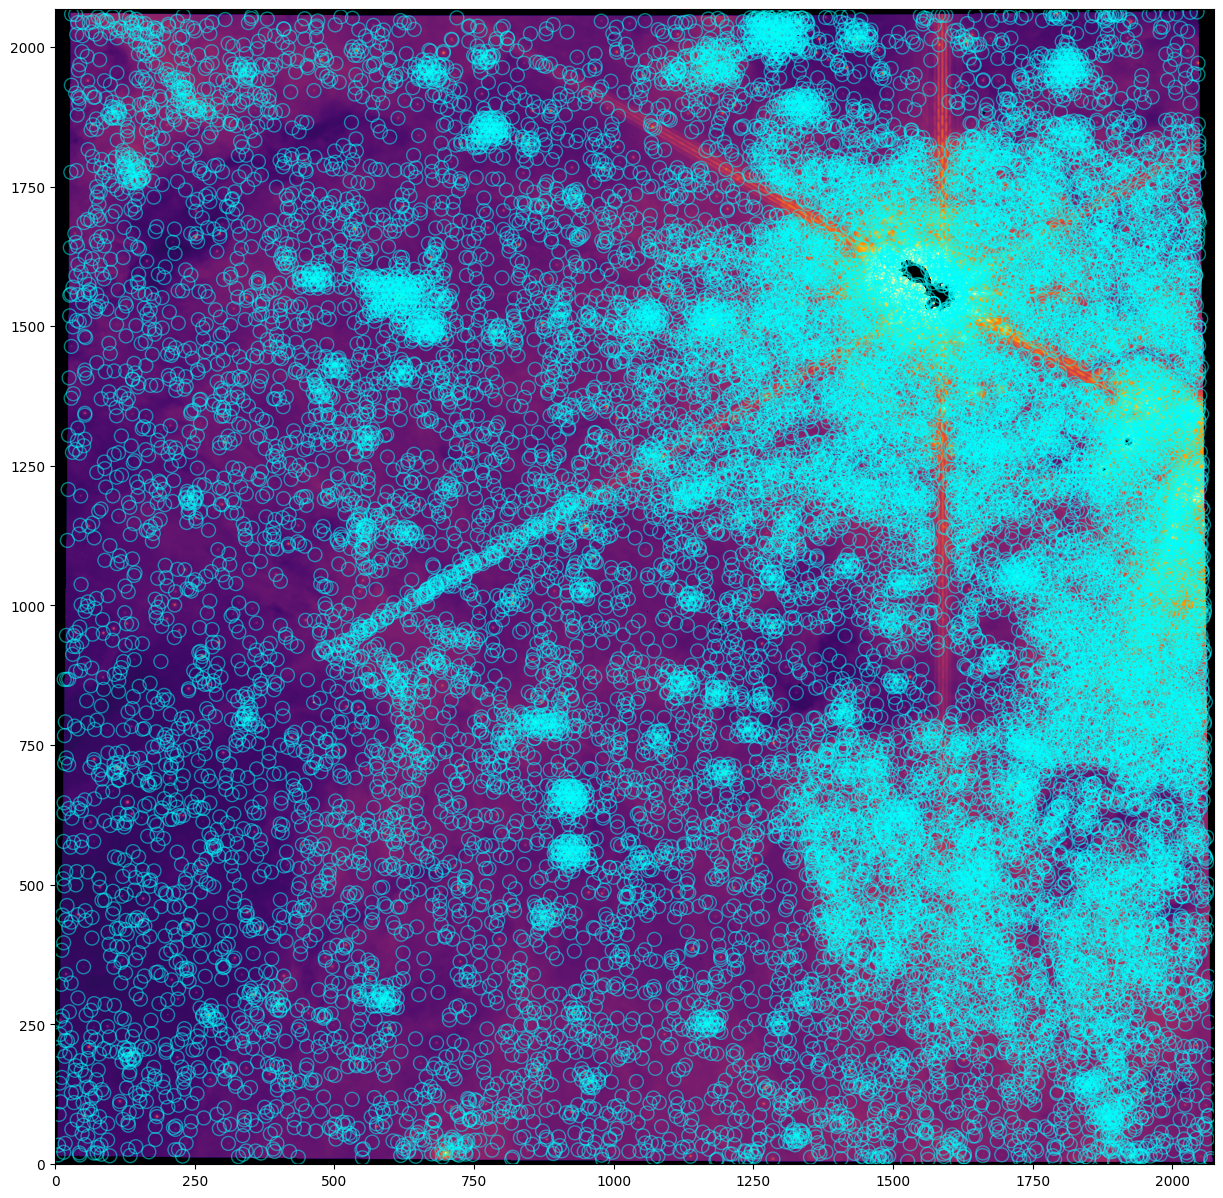

In [2]:
main()